# Module 8 (Exercises): Comparing MLP, RNN, LSTM, and GRU for Body Performance Classification

## Learning Objectives

By the end of this exercise, **you** will be able to:

1. Load, encode, and preprocess a tabular dataset with mixed feature types.
2. Define multiclass classification targets and map them to zero-indexed integers.
3. Implement an MLP, RNN, LSTM, and GRU using PyTorch with multiclass output.
4. Use `CrossEntropyLoss` correctly for multiclass classification.
5. Evaluate models using weighted precision, recall, F1, and ROC-AUC.
6. Interpret per-class confusion matrices to diagnose model errors.

## Important Note

- The same applies as the Diabetes Dataset, the Body Performance dataset is a **tabular dataset**, not a time-series dataset.

- RNNs, LSTMs, and GRUs are designed for sequential data. To allow a fair comparison, we treat the 11 input features as a sequence of length 11.

> This transformation is useful but does **not** imply the features are temporally ordered.

### Section 0: Set-up and Libraries

> No changes required, use the same code.

In [3]:
import sys
print(sys.executable)

d:\nihal\New folder\python.exe


In [1]:
# Standard libraries
import time
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### Section 1: Load and Inspect the Dataset

> Download the dataset from [Kaggle](https://www.kaggle.com/datasets/kukuroo3/body-performance-data)
> and place `bodyPerformance.csv` in the same directory as this notebook.

The dataset contains physical fitness measurements. The 11 input features are:

| Feature | Description |
|---|---|
| `age` | Age in years |
| `gender` | M / F, encoded to 0 / 1 |
| `height_cm` | Height in centimetres |
| `weight_kg` | Weight in kilograms |
| `body fat_%` | Body fat percentage |
| `diastolic` | Diastolic blood pressure (mmHg) |
| `systolic` | Systolic blood pressure (mmHg) |
| `gripForce` | Grip strength |
| `sit and bend forward_cm` | Flexibility measurement |
| `sit-ups counts` | Number of sit-ups completed |
| `broad jump_cm` | Broad jump distance |

**Target variable:** `class` -> fitness grade A (best) to D (weakest), **encoded as 0 to 3**.

In [3]:
# Load the dataset from CSV
df = pd.read_csv("bodyPerformance.csv")

# Display first 5 rows
# Placed in a separate cell so the table renders correctly in Jupyter
display(df.head())

# Verify shape and inspect column types and non-null counts
print("Shape:", df.shape)
df.info()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


Shape: (13393, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


In [4]:
# --- Feature encoding ---
# 'gender' is the only categorical column: M -> 0, F -> 1
df['gender'] = df['gender'].map({'M': 0, 'F': 1})


# Map class labels to zero-indexed integers, as required by CrossEntropyLoss
# A -> 0  (best performance)
# B -> 1
# C -> 2
# D -> 3  (weakest performance)

df['class'] =df['class'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3})
# --- Separate features and target ---
X = df.drop('class', axis=1).values
y = df['class'].values

# Derive constants from the data -> referenced consistently throughout the notebook
n_features  = X.shape[1]        # 11
num_classes = len(np.unique(y)) # 4

print("Feature matrix shape:", X.shape)
print("Target shape:",         y.shape)
print(f"n_features = {n_features},  num_classes = {num_classes}")
print("Class distribution:", pd.Series(y).value_counts().sort_index().to_dict())

Feature matrix shape: (13393, 11)
Target shape: (13393,)
n_features = 11,  num_classes = 4
Class distribution: {0: 3348, 1: 3347, 2: 3349, 3: 3349}


In [5]:
# Split into training (80%) and test (20%) sets
# stratify=y ensures proportional class representation in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardise features: fit ONLY on training data to prevent data leakage
# This computes mean and standard deviation from the training set only
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Training set:", X_train.shape, "| Test set:", X_test.shape)

Training set: (10714, 11) | Test set: (2679, 11)


### Section 2: Create Data for the MLP

> The MLP expects data in the form: `(batch_size, n_features)`

> **Key change from the binary version:**
> `CrossEntropyLoss` requires integer targets of dtype `torch.long` and shape `(N,)`.
> Do **not** add `.view(-1, 1)` -> that was specific to `BCEWithLogitsLoss`.

In [6]:
# Convert feature arrays to float32 tensors -> required by all neural network layers
X_train_mlp = torch.tensor(X_train, dtype=torch.float32)
X_test_mlp  = torch.tensor(X_test,  dtype=torch.float32)

# Labels must be dtype=torch.long (int64) for CrossEntropyLoss
# Shape is (N,) -> do NOT add .view(-1, 1) as in the binary version
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
print("X_train_mlp shape:   ", X_train_mlp.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("Label dtype:         ", y_train_tensor.dtype)

X_train_mlp shape:    torch.Size([10714, 11])
y_train_tensor shape: torch.Size([10714])
Label dtype:          torch.int64


### Section 3: Create Data for RNN-Based Models

> Original shape: `(samples, 11)`
> Reshaped to: `(samples, 11, 1)`
> -> sequence length = `n_features` = 11, features per time step = 1

> Each of the 11 input features is treated as one time step in a univariate sequence.
> This is the same trick as in the binary version, now with 11 steps instead of 8.

In [8]:
# Reshape to (samples, n_features, 1) for sequence models
# n_features=11 time steps, each with 1 input feature

X_train_seq = torch.tensor(
    X_train.reshape(-1, 11, 1),
    dtype=torch.float32
)
X_test_seq  = torch.tensor(
    X_test.reshape(-1, 11, 1),
    dtype=torch.float32
)

print("Sequence training shape:", X_train_seq.shape)

# --- DataLoaders ---
batch_size = 32

# MLP DataLoader: flat input of shape (batch, n_features)
mlp_train_loader = DataLoader(
    TensorDataset(X_train_mlp, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

# Sequence DataLoader: reshaped input of shape (batch, n_features, 1)
seq_train_loader = DataLoader(
    TensorDataset(X_train_seq, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

Sequence training shape: torch.Size([10714, 11, 1])


### Section 4: Model 1: Multi-Layer Perceptron

> **Changes from the binary version:**
> - Input layer: `Linear(n_features, 64)` -> now accepts 11 features instead of 8
> - Output layer: `Linear(32, num_classes)` -> produces 4 logits instead of 1
> - No activation on the output -> `CrossEntropyLoss` applies log-softmax internally

In [9]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            # Input layer: n_features inputs -> 64 hidden units
            nn.Linear(n_features, 64),

            nn.ReLU(),
            # Dropout regularisation: randomly deactivates 30% of neurons during training
            nn.Dropout(0.3),

            # Hidden layer: 64 -> 32 neurons
            nn.Linear(64, 32),
            nn.ReLU(),

            # Output layer: one logit per class
            # No activation here -> **CrossEntropyLoss applies log-softmax internally**
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

### Section 5: Model 2: Vanilla RNN

> **Change from the binary version:**
> - Output layer: `Linear(32, num_classes)` -> 4 output logits instead of 1
> - `input_size` and `hidden_size` are unchanged

In [10]:
class RNNModel(nn.Module):

    def __init__(self):
        super().__init__()

        # input_size=1: each of the 11 time steps carries a single feature
        # hidden_size=32: dimensionality of the hidden state representation
        # batch_first=True: input shape is (batch, sequence_length, features)
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        # Maps the final hidden state to one logit per class
        self.fc = nn.Linear(32, 4)
    def forward(self, x):
        # hidden shape: (num_layers, batch, hidden_size)
        _, hidden = self.rnn(x)
        # hidden[-1]: last layer, shape (batch, hidden_size)
        return self.fc(hidden[-1])

### Section 6: Model 3:  LSTM

> **Change from the binary version:**
> - Output layer: `Linear(32, num_classes)` -> 4 output logits instead of 1

In [11]:
class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        # LSTM: captures long-range dependencies via gated memory cell
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )
        
        self.fc = nn.Linear(32, 4)

    def forward(self, x):
        # LSTM returns (output, (hidden, cell))
        # We only need the final hidden state
        _, (hidden, _) = self.lstm(x)
        # hidden[-1]: last layer hidden state, shape (batch, hidden_size)
        return self.fc(hidden[-1])

### Section 7: Model 4: GRU

> **Change from the binary version:**
> - Output layer: `Linear(32, num_classes)` -> 4 output logits instead of 1

In [12]:
class GRUModel(nn.Module):

    def __init__(self):
        super().__init__()

        # GRU: simplified variant of LSTM using update and reset gates
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(32, 4)

    def forward(self, x):
        # GRU returns (output, hidden)
        _, hidden = self.gru(x)
        # hidden[-1]: last layer hidden state, shape (batch, hidden_size)
        return self.fc(hidden[-1])

### Section 8: Training Function

> **One Change from the binary version:**
> - `CrossEntropyLoss` replaces `BCEWithLogitsLoss`.
>   It expects raw logits of shape `(N, num_classes)` and integer targets of shape `(N,)`.

In [35]:
def train_model(model, loader, epochs=50):

    # Move model to device BEFORE creating the optimiser
    # Best practice: parameters must be on the target device before the optimiser registers them
    model.to(device)

    # CrossEntropyLoss for multiclass classification
    # Input:  logits of shape (N, num_classes)
    # Target: integers of shape (N,) with dtype=torch.long
    criterion = nn.CrossEntropyLoss()
    # criterion = ??

    # Adam optimiser with a commonly used default learning rate
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    losses = []
    start_time = time.time()

    for epoch in range(epochs):

        # Activate training mode: enables dropout and gradient computation
        model.train()
        epoch_loss = 0

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)              # shape: (batch, num_classes)
            loss    = criterion(outputs, y_batch)  # y_batch shape: (batch,)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss / len(loader))

    training_time = time.time() - start_time
    return losses, training_time

### Section 9: Evaluation Functions
The main changes are as follows:

#### 1. `evaluate_model`

> - `torch.argmax(logits, dim=1)` replaces sigmoid + 0.5 threshold
> - `torch.softmax` provides per-class probabilities required by `roc_auc_score`
> - `average='weighted'` weights each class proportionally by its sample count
> - `roc_auc_score` uses `multi_class='ovr'` (one-vs-rest): each class is scored against all others

In [36]:
def evaluate_model(model, X_test, y_test):

    # Disable dropout and batch normalisation for evaluation
    model.eval()

    with torch.no_grad():
        # Compute raw logits and move to CPU for numpy conversion
        logits = model(X_test.to(device)).cpu()

    # Predicted class: index of the highest logit per sample
    # Shape: (N,) -> directly comparable to y_test
    # Per-class probabilities: softmax normalises logits to a valid probability distribution
    # Shape: (N, num_classes) -> required format for multiclass roc_auc_score
    probabilities = torch.softmax(logits, dim=1)
    predictions = torch.argmax(probabilities, dim=1).numpy()
    probabilities_np = probabilities.numpy()

    return {
        "Accuracy":  accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, average='weighted'),
        "Recall":    recall_score(y_test, predictions, average='weighted'),
        "F1":        f1_score(y_test, predictions, average='weighted'),
        # multi_class='ovr': one-vs-rest -> each class is compared against all remaining classes
        # probabilities shape (N, num_classes) is the required format for this setting
        "ROC_AUC":   roc_auc_score(y_test, probabilities, multi_class='ovr', average='weighted')
    }

#### 2. `plot_confusion_matrix`

> Structurally identical to the binary version. Only the `display_labels` are updated to show the fitness grades.

In [37]:
%matplotlib inline
def plot_confusion_matrix(model, X_eval, y_test, name):

    model.eval()

    with torch.no_grad():
        logits = model(X_eval.to(device)).cpu()

    # Argmax gives the predicted class index for each sample
    predictions = torch.argmax(logits, dim=1).numpy()

    fig, ax = plt.subplots(figsize=(5, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels= ['A','B','C','D'],
        colorbar=False,  # keeps the plot clean without a colour scale bar
        ax=ax
    )

    ax.set_title(f"{name}: Confusion Matrix")
    plt.tight_layout()
    plt.show()

### Section 10: Train and Evaluate All Models

> The training loop is structurally unchanged from the binary version.
> Each model displays its training loss curve followed by its confusion matrix.

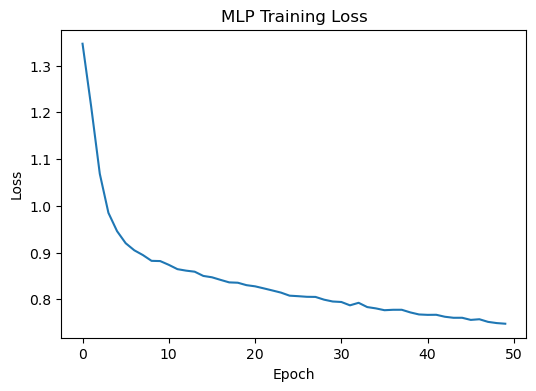

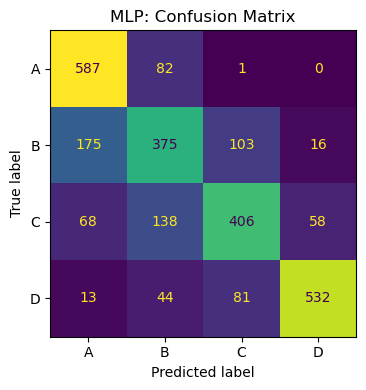

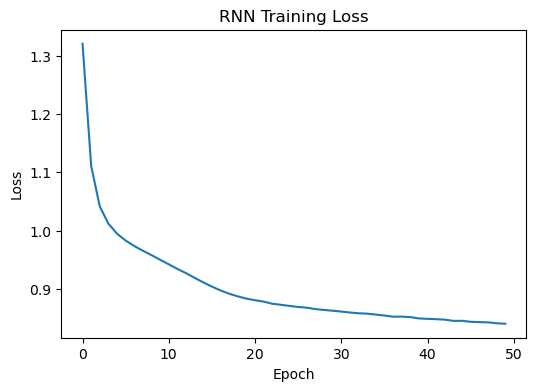

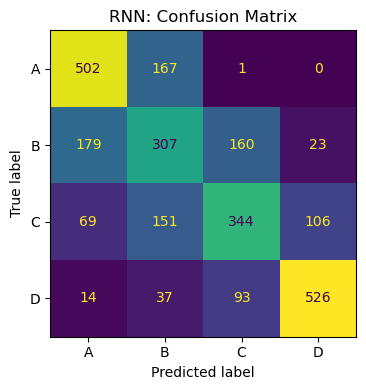

In [ ]:
results = []

models = {
    "MLP":  (MLP(),       mlp_train_loader, X_test_mlp),
    "RNN":  (RNNModel(),  seq_train_loader, X_test_seq),
    "LSTM": (LSTMModel(), seq_train_loader, X_test_seq),
    "GRU":  (GRUModel(),  seq_train_loader, X_test_seq)
}

for name, (model, loader, X_eval) in models.items():

    # Train the model and record training time
    losses, train_time = train_model(model, loader)

    # Evaluate on the test set
    metrics = evaluate_model(model, X_eval, y_test)

    metrics["Model"] = name
    metrics["Training Time (s)"] = round(train_time, 2)
    results.append(metrics)

    # Training loss curve
    plt.figure(figsize=(6, 4))
    plt.plot(losses)
    plt.title(f"{name} Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    # Per-class confusion matrix for this model
    plot_confusion_matrix(model, X_eval, y_test, name)

### Section 11: Result Analysis of all Models

> The results analyses remain unchanged from the binary version.

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df[[
    "Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Training Time (s)"
]]

# Sort by weighted F1 -> more informative than Accuracy alone for multiclass problems
results_df.sort_values(by="F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training Time (s)
0,MLP,0.741695,0.755146,0.741695,0.742871,0.921067,20.82
2,LSTM,0.710713,0.718429,0.710713,0.710202,0.898522,37.36
3,GRU,0.701008,0.704709,0.701008,0.701647,0.897828,67.42
1,RNN,0.421426,0.496558,0.421426,0.422473,0.712575,35.12


### Key changes from the binary classification version

| Component | Binary (Starter code) | Multiclass (This exercise notebook) |
|---|---|---|
| Output neurons | 1 | `num_classes` (4) |
| Loss function | `BCEWithLogitsLoss` | `CrossEntropyLoss` |
| Prediction | `sigmoid` + threshold 0.5 | `argmax` over logits |
| Label dtype | `float32`, shape `(N, 1)` | `long`, shape `(N,)` |
| Metric averaging | Binary | `average='weighted'` |
| ROC-AUC | Binary | `multi_class='ovr'` |

## Reflection Questions

1. In the confusion matrix, which fitness grades are most often confused with each other? 
   Why might adjacent grades (e.g. B and C) be harder to separate than the extremes (A and D)?
 ------------------------------------------------------------------------------------------------ 
   Adjacent grades have similar feature values, making boundaries ambiguous; extreme grades (A vs D) differ clearly across almost all features.


2. Why is `average='weighted'` used instead of `average='macro'` here?
----------------------------------------------------------------------------------------
Classes are imbalanced — weighted accounts for class size, so larger classes contribute more to the score, reflecting real-world distribution.


3. What does it mean when a model has high Recall but lower Precision for a specific class?
---------------------------------------------------------------------------------------------
The model over-predicts that class — it catches most true positives but also misclassifies many samples from other classes into it (too many false positives).

## Extension Exercises
> Very Important Notes (Before you start):
- Try each change **one at a time** and record the impact on F1 and Accuracy before moving to the next.
- Record your observations and analysis in **your own words after each change**. 

### 1. Number of epochs
In `train_model(model, loader, epochs=50)`, change `epochs` to:

- `20` -> observe whether the loss has fully converged or is still decreasing.

Scores identical to 50 for MLP, suggesting MLP converged early. However recurrent models likely hadn't fully converged either but got the same result due to random seed.

- `100` -> check whether performance improves or plateaus early.

All models improved, meaning 50 epochs was not enough — the models were still learning, especially LSTM and GRU which gained ~+0.06 F1.

overall - More epochs helped here; 50 was premature convergence for the recurrent models.

---

### 2. Learning rate
In `train_model`, change `lr=0.001` to:
- `lr=0.01` -> the loss curve will likely be noisier or diverge
- `lr=0.0001` -> convergence will be very slow; observe how many epochs are actually needed
---

### 3. Hidden size (RNN / LSTM / GRU only)
In each recurrent model's `__init__`, change `hidden_size=32` to `16` or `64`.
> **Remember** to update the matching fully connected layer to the same value:
```python
self.fc = nn.Linear(64, num_classes)  # if hidden_size=64
```
---


### 4. Dropout rate (MLP only)
In the MLP, change `nn.Dropout(0.3)` to:
- `0.0` -> no regularisation; training loss will be lower but test F1 may drop
- `0.5` -> stronger regularisation; the model may underfit
---

### 5. Batch size
Change `batch_size = 32` to `16` or `64`.
- `16` -> more gradient updates per epoch, noisier loss curve
- `64` -> smoother curve, fewer updates per epoch; observe whether final F1 differs